In [2]:
import os
from pathlib import Path
from multiprocessing import Pool
import networkx as nx
from tqdm import tqdm
import numpy as np
import pandas as pd
from util.util_jk import loadnii
from vvl.utils.GraphInfo import GraphInfo
from project.pipeline.repro.qc_files import filterOptomicsScans 


toolbox_path C:\Users\go34nuy\projects\rsom-toolbox


In [4]:
## double check layseg shape

layse_old = r"C:\Users\go34nuy\data\Repro\timeseries\processed\epidermis_segmentation\R_TS1_151927_S2.nii.gz"
layseg_new = r"D:\data\UTartu\processed\epidermis_segmentation\R_G000452190_LEG_Scan00013_img.nii.gz"


layseg = loadnii(layse_old)
layseg = np.array(layseg, dtype=np.float32)
# layseg_a = layseg.transpose(1, 0, 2)
layseg_a = layseg.transpose(0, 1, 2)


layseg = loadnii(layseg_new)
layseg = np.array(layseg, dtype=np.float32)
# layseg_b = layseg.transpose(2,1,0)
layseg_b = layseg.transpose(0, 1, 2)

print(layseg_a.shape)
print(layseg_b.shape)


(672, 160, 328)
(328, 160, 1176)


In [28]:
from util.util_jk import loadmat
recon_lf = loadmat(r"C:\Users\go34nuy\data\Repro\timeseries\processed\recon\R_TS1_151824_S1LF.mat")['R']
# recon_hf = loadmat(recon_hf_path)['R']

# recon_hf = np.transpose(recon_hf, axes = (1,0,2))
recon_lf = np.transpose(recon_lf, axes = (1,2,0))
recon_lf.shape

(328, 160, 672)

In [2]:
import os
from pathlib import Path
from multiprocessing import Pool
import networkx as nx
from tqdm import tqdm
import numpy as np
import pandas as pd
from util.util_jk import loadnii
from vvl.utils.GraphInfo import GraphInfo
from project.pipeline.repro.qc_files import filterOptomicsScans 


paths__list = [
# [r"C:\Users\go34nuy\data\Repro\test\processed\vessel_segmentation",
# r"C:\Users\go34nuy\data\Repro\test\processed\epidermis_segmentation"],

# [r"C:\Users\go34nuy\data\Repro\FOV\processed\vessel_segmentation",
# r"C:\Users\go34nuy\data\Repro\FOV\processed\epidermis_segmentation"],

# [r"\\nas.ads.mwn.de\tuze\t01\AG-Ntziachristos\RSOM_Data\forErik\timeseries\processed\new_vessegs",
# r"\\nas.ads.mwn.de\tuze\t01\AG-Ntziachristos\RSOM_Data\forErik\timeseries\processed\new_laypreds"],

# [r"C:\Users\go34nuy\data\Repro\timeseries\processed\vessel_segmentation",
# r"C:\Users\go34nuy\data\Repro\timeseries\processed\epidermis_segmentation"],

[r"D:\data\UTartu\processed\vessel_segmentation",
 r"D:\data\UTartu\processed\epidermis_segmentation"],

]


for vesselseg_dir, layerseg_dir in paths__list:

    # print(vesselseg_dir, layerseg_dir)

    filter_length = 0.250  # remove paths with a length less than this
    prune_length = 0.0  # remove connected endpoint vessels with length less than this
    large_vessel_radius = 14.4  # Manually define at which radius vessels are considered large
    vp_depth = 40  # Depth at which to seperate the vessels into upper and lower region
    legacy = True  # If using new vesselseg like synthetic vesselseg this Flag needs to be set to true  #####for synthetic vesseg set to False, else True
    normalize = False # If vessel signal is already cropped to normalized volume then don't need to normalize

    if legacy:
        resolution = [0.012, 0.012, 0.003]  # Legacy axes order (z,y,x)
    else:
        resolution = [0.003, 0.012, 0.012]  # Fabian axes order x,y,z)


    def find_layseg_for_vesseg(vesseg_path, layseg_dir):
        def clean_up_name(name):
            name = name.replace("_processed", "")
            name = name.replace("__l", "")
            name = name.replace("_l", "")
            name = name.replace("_0000", "")
            name = name.replace("_0001", "")
            name = name.replace(".nii.gz", "")
            return name

        lays = os.listdir(layseg_dir)
        for lay in lays:
            if clean_up_name(lay) == clean_up_name(os.path.basename(vesseg_path)):
                return os.path.join(layseg_dir, lay)
        raise ValueError(f"No matching layseg found for {vesseg_path} in {layseg_dir}")


    def extract_graph_wrapper(g_i):
        g_i.extract_graph()
        return g_i


    def extract_radii_wrapper(g_i):
        return g_i.extract_radius()


    def extract_sizefeats_wrapper(g_i):
        # g_i.extract_features()
        g_i.extract_features_upper_lower()

        return g_i


    def flatten_coords(coords, surface, depth):
        coords = np.asarray(coords)
        yx = coords[:,[0,1]].round().astype(int)
        shift = depth - surface[yx[:,0], yx[:,1]]
        coords[:,2] += shift
        return coords
    
    def surfaceToMask(surface:np.ndarray, Nz:int, width:int=1):
        Nx, Ny = surface.shape
        surface = np.clip(surface, 0, Nz-1)
        mask = np.zeros(shape=(Nx, Ny, Nz), dtype=np.int8)
        for i in range(Nx):
            for j in range(Ny):
                mask[i, j, int(surface[i, j]):int(surface[i, j] + width)]=1
        return mask

    def get_vp_depth(graph_path, layseg_path):

        layseg = loadnii(layseg_path)
        layseg = np.array(layseg, dtype=np.float32)
        layseg = layseg.transpose(1, 0, 2)
        print(layseg.shape)
        G = nx.read_graphml(graph_path)
        nodes = []
        for n, d in G.nodes(data=True):
            x, y, z = float(d['X']), float(d['Y']), float(d['Z'])
            nodes.append([y, z, x])   # napari expects (z,y,x)

        junction_surface = layseg.shape[2] - 1 - np.argmax(np.flip(layseg, axis=2), axis=2)

        nodes_flat = flatten_coords(nodes, junction_surface, 0)
        z_vals = nodes_flat[:, 2]

        counts, bins = np.histogram(z_vals, bins=30)
        threshold = 0.3 * counts.max()
        z_thr = bins[np.where(counts >= threshold)[0][-1]]
        vp_depth = np.max(abs(z_vals))-abs(z_thr)
        return vp_depth
     

    if __name__ == "__main__":
        results_folder = os.path.join(vesselseg_dir, "vesselvio")
        Path(results_folder).mkdir(parents=True, exist_ok=True)

        graph_infos = []
        # Load all files
        print("Loading files...")
        subj_scans_ignore = []#filterOptomicsScans()
        segs = [seg for seg in os.listdir(vesselseg_dir) if ".nii.gz" in seg and not any(ig in seg for ig in subj_scans_ignore)] ###added to skip ignore scans



        ###determine depth
        # segs = segs[160:164]
        # segs = [r"\\nas.ads.mwn.de\tume\bb1\IBMI_Clinical_Studies\OPTOMICS_1.1-12-2348-EST_UTARTU\processed_ds12_dz3\vessel_segmentation\R_S_G000452190_LEG_Scan00013_img.nii.gz"]#, r"C:\Users\go34nuy\data\Repro\MMS\processed\vessel_segmentation\R_MMS018_N0_AO_r2.nii.gz"]
        for vesselseg_name in tqdm(segs):

            # if not 'LEG' in vesselseg_name:
            #     continue
            

            vesselseg_path = os.path.join(vesselseg_dir, vesselseg_name)

            p = Path(vesselseg_path)
            base = p.stem[:-4]  # R_TS5_145119_s10              
            recon_lf_path = p.parents[1] / "recon" / f"{base}LF.mat"
            recon_hf_path = p.parents[1] / "recon" / f"{base}HF.mat"


            graph_path = p.parents[1] / "features" / "Graphs" / f"{base}.graphml"
            layseg_path = p.parents[1] / "epidermis_segmentation" / f"{base}.nii.gz"
            vp_depth = get_vp_depth(graph_path, layseg_path)
            print(graph_path, vp_depth)

Loading files...


  0%|          | 0/481 [00:00<?, ?it/s]

(160, 328, 1176)


  0%|          | 1/481 [00:00<02:44,  2.92it/s]

D:\data\UTartu\processed\features\Graphs\R_G000452190_LEG_Scan00013_img.graphml 34.19999999999999
(160, 328, 1176)


...

D:\data\UTartu\processed\features\Graphs\R_G020521550_LEG_Scan00013_img.graphml 41.0
(160, 328, 1176)


  3%|▎         | 15/481 [00:05<03:19,  2.34it/s]

D:\data\UTartu\processed\features\Graphs\R_G020521550_LEG_Scan00014_img.graphml 34.0
(160, 328, 1176)


  3%|▎         | 15/481 [00:05<02:49,  2.75it/s]


KeyboardInterrupt: 

In [2]:
vesselseg_path

'D:\\data\\UTartu\\processed\\vessel_segmentation\\R_G858806590_LEG_Scan00013_img.nii.gz'

In [13]:
p.parents[1] / "features" / "Graphs" / f"{base}.graphml"

WindowsPath('D:/data/UTartu/processed/features/Graphs/R_G858806590_LEG_Scan00013_img.graphml')

In [14]:
p.parents[1] / "epidermis_segmentation" / f"{base}.nii.gz"

WindowsPath('D:/data/UTartu/processed/epidermis_segmentation/R_G858806590_LEG_Scan00013_img.nii.gz')

In [ ]:
nx_graph = r"C:\Users\go34nuy\data\Repro\MMS\processed\vessel_segmentation\vesselvio\Graphs\R_MMS018_N0_AO_r2_upper.graphml"
igraph = r"C:\Users\go34nuy\data\Repro\MMS\processed\vessel_segmentation\vesselvio\Graphs\R_MMS018_N0_AO_r2_lower.graphml"

In [2]:
from util.util_jk import loadmat
from vvl.utils.image_processing import load_volume
import numpy as np

recon_lf_path = r"C:\Users\go34nuy\data\Repro\test\processed\recon\R_CF_ER01_P1LF.mat"
recon_hf_path = r"C:\Users\go34nuy\data\Repro\test\processed\recon\R_CF_ER01_P1HF.mat"
vesseg_path_upper = r"C:\Users\go34nuy\data\Repro\test\processed\vessel_segmentation\vesselvio\R_CF_ER01_P1_upper.nii.gz"
vesseg_path_lower = r"C:\Users\go34nuy\data\Repro\test\processed\vessel_segmentation\vesselvio\R_CF_ER01_P1_lower.nii.gz"
layseg_path = r"C:\Users\go34nuy\data\Repro\test\processed\epidermis_segmentation\R_CF_ER01_P1.nii.gz"


LAY, _ = load_volume(layseg_path)
VES_upp, _ = load_volume(vesseg_path_upper)
VES_low, _ = load_volume(vesseg_path_lower)
LF = np.transpose(loadmat(recon_lf_path)['R'], axes = (1,2,0))
HF = np.transpose(loadmat(recon_hf_path)['R'], axes = (1,2,0))

VES_upp, VES_low = VES_upp.T, VES_low.T 


LAY = np.array(LAY, dtype=np.float32)
VES_upp = np.array(VES_upp, dtype=np.float32)
VES_low = np.array(VES_low, dtype=np.float32)

HF = np.clip(HF, 0, np.max(HF))
LF = np.clip(LF, 0, np.max(LF))

In [ ]:

dist_transducer = np.mean(np.argmax(LAY, axis=2))
dist_transducer

array([[215, 215, 211, ..., 211, 214, 214],
       [215, 215, 211, ..., 211, 214, 214],
       [215, 214, 212, ..., 211, 214, 214],
       ...,
       [259, 259, 259, ..., 253, 254, 254],
       [259, 259, 259, ..., 254, 254, 254],
       [259, 259, 259, ..., 254, 254, 254]], dtype=int64)

In [3]:
print('LAY', LAY.shape)
print('VES_upp', VES_upp.shape)
print('VES_low', VES_low.shape)
print('LF', LF.shape)
print('HF', HF.shape)

LAY (328, 160, 1176)
VES_upp (328, 160, 123)
VES_low (328, 160, 238)
LF (328, 160, 1176)
HF (328, 160, 1176)


In [35]:
HF.max()

230774.14

In [31]:
features = {}

def layseg_int_features():
    layseg_hf = HF[LAY == 1]
    layseg_lf = LF[LAY == 1]

    layseg_int_max_hf = layseg_hf.max()
    layseg_int_mean_hf = layseg_hf.mean()
    layseg_int_max_lf = layseg_lf.max()
    layseg_int_mean_lf = layseg_lf.mean()

    depth_counts = np.sum(LAY > 0, axis=-1)  # shape: (y, x)
    layseg_depth = np.mean(depth_counts[depth_counts > 0])

    return {"layseg_int_max_hf": layseg_int_max_hf, ###welche einheit, warum values so groß?
            "layseg_int_mean_hf": layseg_int_mean_hf,
            "layseg_int_max_lf": layseg_int_max_lf,
            "layseg_int_mean_lf": layseg_int_mean_lf,
            "layseg_depth [um]": int(layseg_depth * 3),
            }

def upper_int_features():
    shifted_vesseg_upp = np.zeros(HF.shape, dtype=HF.dtype)
    shift = np.min(depth_map_full)
    shifted_vesseg_upp[:,:,shift:shift+VES_upp.shape[2]] = VES_upp

    vesseg_upper_hf = HF[shifted_vesseg_upp == 1]
    layseg_upper_lf = LF[shifted_vesseg_upp == 1]

    vesseg_upper_int_max_hf = vesseg_upper_hf.max()
    vesseg_upper_int_mean_hf = vesseg_upper_hf.mean()
    vesseg_upper_int_max_lf = layseg_upper_lf.max()
    vesseg_upper_int_mean_lf = layseg_upper_lf.mean()

    return {"vesseg_upper_int_max_hf": vesseg_upper_int_max_hf, ###welche einheit, warum values so groß?
            "vesseg_upper_int_mean_hf": vesseg_upper_int_mean_hf,
            "vesseg_upper_int_max_lf": vesseg_upper_int_max_lf,
            "vesseg_upper_int_mean_lf": vesseg_upper_int_mean_lf,
            }


def lower_int_features():
    shifted_vesseg_low = np.zeros(HF.shape, dtype=HF.dtype)
    shift = np.min(depth_map_full)+upper_lower_depth
    shifted_vesseg_low[:,:,shift:shift+VES_low.shape[2]] = VES_low

    vesseg_lower_hf = HF[shifted_vesseg_low == 1]
    layseg_lower_lf = LF[shifted_vesseg_low == 1]

    vesseg_lower_int_max_hf = vesseg_lower_hf.max()
    vesseg_lower_int_mean_hf = vesseg_lower_hf.mean()
    vesseg_lower_int_max_lf = layseg_lower_lf.max()
    vesseg_lower_int_mean_lf = layseg_lower_lf.mean()

    return {"vesseg_lower_int_max_hf": vesseg_lower_int_max_hf, ###welche einheit, warum values so groß?
            "vesseg_lower_int_mean_hf": vesseg_lower_int_mean_hf,
            "vesseg_lower_int_max_lf": vesseg_lower_int_max_lf,
            "vesseg_lower_int_mean_lf": vesseg_lower_int_mean_lf,
            }


upper_lower_depth = 40
depth_map_full = LAY.shape[2] - np.argmax(LAY[...,::-1], axis=2)


features.update(layseg_int_features())
features.update(upper_int_features())
features.update(lower_int_features())
features

{'layseg_int_max_hf': 217090.94,
 'layseg_int_mean_hf': 3273.4937,
 'layseg_int_max_lf': 158486.16,
 'layseg_int_mean_lf': 6499.319,
 'layseg_depth [um]': 84,
 'vesseg_upper_int_max_hf': 230774.14,
 'vesseg_upper_int_mean_hf': 17178.867,
 'vesseg_upper_int_max_lf': 186410.39,
 'vesseg_upper_int_mean_lf': 30269.857,
 'vesseg_lower_int_max_hf': 171287.73,
 'vesseg_lower_int_mean_hf': 10006.179,
 'vesseg_lower_int_max_lf': 195380.27,
 'vesseg_lower_int_mean_lf': 28580.277}

In [32]:
shifted_vesseg_upp = np.zeros(HF.shape, dtype=HF.dtype)
shift = np.min(depth_map_full)
shifted_vesseg_upp[:,:,shift:shift+VES_upp.shape[2]] = VES_upp

vesseg_upper_hf = HF[shifted_vesseg_upp == 1]
layseg_upper_lf = LF[shifted_vesseg_upp == 1]

In [ ]:
upper_lower_depth = 40

depth_map_full = LAY.shape[2] - np.argmax(LAY[...,::-1], axis=2)

shifted_vesseg_upp = np.zeros(HF.shape, dtype=HF.dtype)
shift = np.min(depth_map_full)
shifted_vesseg_upp[:,:,shift:shift+VES_upp.shape[2]] = VES_upp

shifted_vesseg_low = np.zeros(HF.shape, dtype=HF.dtype)
shift = np.min(depth_map_full)+upper_lower_depth
shifted_vesseg_low[:,:,shift:shift+VES_low.shape[2]] = VES_low

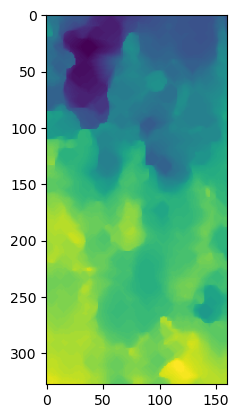

In [29]:
import matplotlib.pyplot as plt

plt.imshow(depth_map_full)

In [ ]:
import napari

viewer = napari.Viewer(ndisplay=3)
viewer.add_image(HF, colormap='green')
viewer.add_image(LF, colormap='red')
viewer.add_image(VES_upp, opacity=0.5, blending='additive', colormap='grey', name='VES_upp')
viewer.add_image(shifted_vesseg_upp, opacity=0.5, blending='additive', colormap='grey',  name='VES_upp_shift')
viewer.add_image(VES_low, opacity=0.5, blending='additive', colormap='grey', name='VES_low')
viewer.add_image(shifted_vesseg_low, opacity=0.5, blending='additive', colormap='grey',  name='VES_low_shift')
viewer.add_image(LAY, opacity=0.5, blending='additive', colormap='grey',  name='LAY')
        
napari.run()

ValueError: Image data must have at least 2 dimensions.

In [ ]:
paths__list = [
[r"C:\Users\go34nuy\data\Repro\ContactForce\processed\vessel_segmentation",
r"C:\Users\go34nuy\data\Repro\ContactForce\processed\epidermis_segmentation"],

[r"C:\Users\go34nuy\data\Repro\MMS\processed\vessel_segmentation",
r"C:\Users\go34nuy\data\Repro\MMS\processed\epidermis_segmentation"]

]


for path_list in paths__list:
    vesselseg_dir = path_list[0]
    layerseg_dir = path_list[1]
    
    print(vesselseg_dir, layerseg_dir)

C:\Users\go34nuy\data\Repro\ContactForce\processed\vessel_segmentation C:\Users\go34nuy\data\Repro\ContactForce\processed\epidermis_segmentation
C:\Users\go34nuy\data\Repro\MMS\processed\vessel_segmentation C:\Users\go34nuy\data\Repro\MMS\processed\epidermis_segmentation


In [ ]:
vesselseg_dir = r"C:\Users\go34nuy\data\Repro\MMS\processed\vessel_segmentation"
vesselseg_name = r'R_MMS001_N0_AO_b.nii.gz'
import os

vesselseg_path = os.path.join(vesselseg_dir, vesselseg_name) 
upper_path = os.path.join(vesselseg_dir, 'vesselvio', f'{vesselseg_name[:-7]}_upper.nii.gz') 

if os.path.exists(upper_path):
    continue   

'C:\\Users\\go34nuy\\data\\Repro\\MMS\\processed\\vessel_segmentation\\vesselvio\\R_MMS001_N0_AO_b_upper.nii.gz'